# Phase 1: EDA & Data Cleaning

**Owner:** Fiona  
**Focus:**  
- Merge `df_final_web_data_pt_1` and `df_final_web_data_pt_2`  
- Clean `df_final_demo`  
- Complete EDA for client **age**, **tenure**, and **gender**  

## 1. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Datasets

In [28]:
demo = pd.read_csv('df_final_demo.txt')
web_1 = pd.read_csv('df_final_web_data_pt_1.txt')
web_2 = pd.read_csv('df_final_web_data_pt_2.txt')

print("demo shape:", demo.shape)
print("web_1 shape:", web_1.shape)
print("web_2 shape:", web_2.shape)

demo shape: (70609, 9)
web_1 shape: (343141, 5)
web_2 shape: (412264, 5)


## 3. Initial Dataset Inspection

In [29]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [30]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [31]:
print("Missing values in demo:")
display(demo.isna().sum())

print("Duplicate rows in demo:", demo.duplicated().sum())

Missing values in demo:


client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

Duplicate rows in demo: 0


In [32]:
web_1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [33]:
web_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     343141 non-null  int64 
 1   visitor_id    343141 non-null  object
 2   visit_id      343141 non-null  object
 3   process_step  343141 non-null  object
 4   date_time     343141 non-null  object
dtypes: int64(1), object(4)
memory usage: 13.1+ MB


In [34]:
print("Missing values in web_1:")
display(web_1.isna().sum())

print("Duplicate rows in web_1:", web_1.duplicated().sum())

Missing values in web_1:


client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

Duplicate rows in web_1: 2095


In [35]:
web_2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [36]:
web_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412264 entries, 0 to 412263
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     412264 non-null  int64 
 1   visitor_id    412264 non-null  object
 2   visit_id      412264 non-null  object
 3   process_step  412264 non-null  object
 4   date_time     412264 non-null  object
dtypes: int64(1), object(4)
memory usage: 15.7+ MB


In [37]:
print("Missing values in web_2:")
display(web_2.isna().sum())

print("Duplicate rows in web_2:", web_2.duplicated().sum())

Missing values in web_2:


client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

Duplicate rows in web_2: 8669


## 4. Merge Web Data

In [38]:
df_web = pd.concat([web_1, web_2], ignore_index=True)

print("Merged web data shape:", df_web.shape)
display(df_web.head())

Merged web data shape: (755405, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


## 5. Clean Web Data

Cleaning steps:
1. Convert `date_time` to datetime format  
2. Remove duplicate rows  
3. Sort records by client, visit, and time  
4. Recheck missing values and duplicates  


In [39]:
df_web['date_time'] = pd.to_datetime(df_web['date_time'], errors='coerce')
df_web = df_web.drop_duplicates()
df_web = df_web.sort_values(['client_id', 'visit_id', 'date_time'])
df_web.head()


,client_id,visitor_id,visit_id,process_step,date_time
285515,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
285514,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
285513,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
285512,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
285511,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09


In [40]:
print("Missing values in cleaned web data:")
display(df_web.isna().sum())

print("Duplicate rows in cleaned web data:", df_web.duplicated().sum())

Missing values in cleaned web data:


client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

Duplicate rows in cleaned web data: 0


## 6. Clean Client Profile Data: `df_final_demo`

In [41]:
demo_clean = demo.copy()
demo_clean = demo_clean.rename(columns={'clnt_tenure_yr': 'client_tenure_years','clnt_tenure_mnth': 'client_tenure_months','clnt_age': 'client_age','gendr': 'gender','bal': 'balance','calls_6_mnth': 'calls_last_6_months','logons_6_mnt': 'logins_last_6_months'})
display(demo_clean.head())

,client_id,client_tenure_years,client_tenure_months,client_age,gender,num_accts,balance,calls_last_6_months,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


### Gender Cleaning Logic
Odd or unclear gender values are changed to `U`, meaning **Unknown**.  

In [42]:
demo_clean['gender'] = demo_clean['gender'].replace({'X': 'U'})
demo_clean['gender'] = demo_clean['gender'].fillna('U')

In [43]:
demo_clean = demo_clean.drop_duplicates()
display(demo_clean.head())

,client_id,client_tenure_years,client_tenure_months,client_age,gender,num_accts,balance,calls_last_6_months,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [44]:
print("Missing values in cleaned demo:")
display(demo_clean.isna().sum())

print("Duplicate rows in cleaned demo:", demo_clean.duplicated().sum())

Missing values in cleaned demo:


client_id                0
client_tenure_years     14
client_tenure_months    14
client_age              15
gender                   0
num_accts               14
balance                 14
calls_last_6_months     14
logons_6_mnth           14
dtype: int64

Duplicate rows in cleaned demo: 0


# 7. EDA: Gender Analysis

In [45]:
gender_counts = demo_clean['gender'].value_counts()
gender_percent = demo_clean['gender'].value_counts(normalize=True) * 100
gender_summary = pd.DataFrame({'count': gender_counts,'percentage': gender_percent.round(2)})
display(gender_summary)

,count,percentage
gender,,
U,24139,34.19
M,23724,33.60
F,22746,32.21


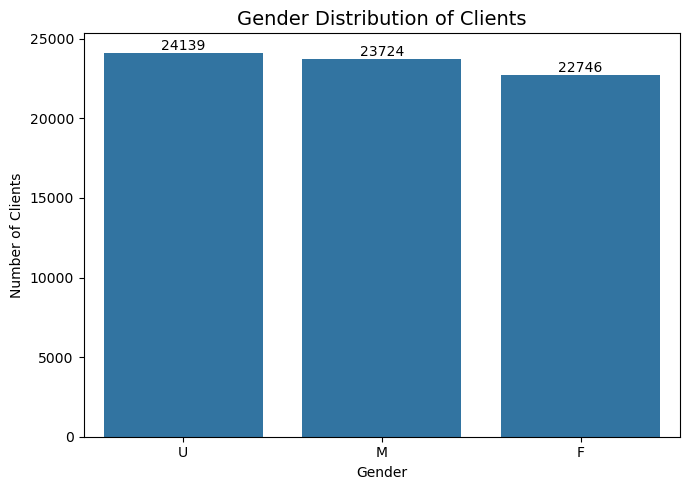

In [49]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=demo_clean,x='gender')
plt.title('Gender Distribution of Clients', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Number of Clients')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

### Gender Insight
- The gender split appears fairly balanced, although the number of clients with unknown gender values is just as large as the male and female groups.

### Phase 1 Summary
#### For Phase 1 of the project, I focused on:
- Merged web datasets using pd.concat()
- Converted datetime columns
- Removed duplicate rows
- Renamed columns for readability
- Cleaned inconsistent gender values
- Performed gender exploratory data analysis
- Created visualizations and percentage summaries